<a href="https://colab.research.google.com/github/ShorouqTelfah/Automated-methods-to-detect-pneumonia-diseases-from-medical-images/blob/main/TRAIN_CNN_VINDRMAMMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Step 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

# Step 2: Create destination folder in your Google Drive
import os

destination = "/content/drive/My Drive/vindr-mammo"
os.makedirs(destination, exist_ok=True)

Mounted at /content/drive


In [2]:
import pandas as pd

# Path to your saved CSV
csv_path = "/content/drive/MyDrive/vindr-mammo/train_image_level.csv"

# Load it
df = pd.read_csv(csv_path)

# Check shape (number of rows and columns)
print("Shape:", df.shape)

# Show first 5 rows
df.head()


Shape: (640, 32)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name,Age Group,stratify_col,dicom_path
0,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,2f6e06d3d3d3b93694f040070ca064d0,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
1,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,65862aee30a500c012c5d5b551daa7af,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
2,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,1cf9fe6c6943d24ffc1977c172aed52a,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
3,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,d87681a1005c500940e40dc27a4b2b5c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
4,99288599d73af38b70043141516a2e49,5f0c048ea425dc0ccb7b8666021ef700,bc9f441425e64b9982168d6f1d3e3bc5,R,MLO,3518,2800,BI-RADS 2,DENSITY D,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY D,/content/drive/MyDrive/160image/physionet.org/...


In [3]:
print(df.columns.tolist())

['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split', 'Series Instance UID', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name", 'Age Group', 'stratify_col', 'dicom_path']


In [4]:
df.sample(5)[["study_id", "image_id", "breast_birads", "dicom_path"]]

,study_id,image_id,breast_birads,dicom_path
117,1acac9be3e482adc17b20ddb36153929,01ea288cea134b2730c5965888e22b73,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
473,1902f78dd41ade9f6f6de8a4e571eb1e,4a97666bfc0fcacbe5509c2bfd9368e9,BI-RADS 2,/content/drive/MyDrive/160image/physionet.org/...
9,5cedbbdb51fc5d53d6c2a263c51d0550,c73c7fdefb65311725fa01da769fa1e4,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
457,23ab4ae895f391e494b0fcb1176daf5c,ca3227a78b72c59139a9dded1d8f85e2,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
601,df0d78ef7e96026ff6a6e2d578890967,ce0fd14f399b96f0c3633fbb65c2f0f8,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...


In [5]:
import os

missing = df[~df["dicom_path"].apply(os.path.exists)]
print(f"Missing files: {len(missing)}")

if len(missing) > 0:
    print(missing["dicom_path"].head())
else:
    print("✅ All DICOM paths are valid!")

Missing files: 0
✅ All DICOM paths are valid!


In [6]:
!pip install pydicom


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.0 MB/s eta 0:00:00


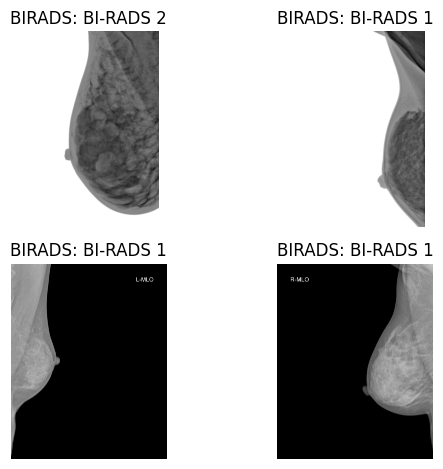

In [7]:
import matplotlib.pyplot as plt
import pydicom
import random

for i in range(4):
    idx = random.randint(0, len(df)-1)
    path = df.iloc[idx]["dicom_path"]
    birads = df.iloc[idx]["breast_birads"]
    ds = pydicom.dcmread(path)
    plt.subplot(2, 2, i+1)
    plt.imshow(ds.pixel_array, cmap='gray')
    plt.title(f"BIRADS: {birads}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
!pip install pydicom matplotlib tensorflow --quiet


In [25]:
# -----------------------------
# Step 0: Imports
# -----------------------------
import os
import numpy as np
import pandas as pd
import cv2
import pydicom
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Step 1: Load CSVs
# -----------------------------
train_csv = "/content/drive/My Drive/vindr-mammo/train_image_level.csv"
test_csv  = "/content/drive/MyDrive/vindr-mammo/test_image_level.csv"

train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (640, 32)
Test shape: (160, 32)


In [10]:
# Step 2: Prepare labels
# -----------------------------
# Drop rows without BI-RADS labels
train_df = train_df.dropna(subset=['breast_birads'])

# Map only existing BI-RADS classes (1-5)
label_map = {
    'BI-RADS 1': 0,
    'BI-RADS 2': 1,
    'BI-RADS 3': 2,
    'BI-RADS 4': 3,
    'BI-RADS 5': 4
}
train_df['label'] = train_df['breast_birads'].map(label_map)

num_classes = len(label_map)  # 5

# Internal train/val split
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")


Train: 512, Validation: 128, Test: 160


In [11]:
# Step 3: Preprocessing function
# -----------------------------
def preprocess_dicom(path, img_size=(224,224)):
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)

    # Normalize to [0,1]
    img -= np.min(img)
    img /= (np.max(img) + 1e-5)

    # Convert to RGB (3 channels)
    img_rgb = np.stack((img,)*3, axis=-1)

    # Resize for CNN
    img_resized = cv2.resize(img_rgb, img_size)

    return img_resized


In [12]:
# Step 4: Data augmentation
# -----------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: x/255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=lambda x: x/255.0)


In [13]:
# Step 5: Generator function
# -----------------------------
def generator(df, batch_size=16, is_train=True):
    while True:
        df = df.sample(frac=1).reset_index(drop=True) if is_train else df
        for start in range(0, len(df), batch_size):
            batch_df = df.iloc[start:start+batch_size]
            X = np.array([preprocess_dicom(p) for p in batch_df['dicom_path']])
            y = to_categorical(batch_df['label'].astype(int), num_classes=num_classes)
            yield X, y

# -----------------------------
# Step 6: Build EfficientNet model
# -----------------------------
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base for transfer learning

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
# Load previous weights if available
# -----------------------------
if os.path.exists("best_model.h5"):
    print("Loading saved weights...")
    model.load_weights("best_model.h5")


In [15]:
# Step 7: Callbacks
# -----------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True)
]


In [18]:
# Step 8: Train model
# -----------------------------
train_gen = generator(train_df, batch_size=16, is_train=True)
val_gen   = generator(val_df, batch_size=16, is_train=False)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_df)//16,
    validation_steps=len(val_df)//16,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4073 - loss: 1.4904 

32/32 ━━━━━━━━━━━━━━━━━━━━ 491s 15s/step - accuracy: 0.4109 - loss: 1.4870 - val_accuracy: 0.6250 - val_loss: 1.1795
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6371 - loss: 1.1307

32/32 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.6367 - loss: 1.1304 - val_accuracy: 0.6250 - val_loss: 1.0493
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6192 - loss: 1.1035

32/32 ━━━━━━━━━━━━━━━━━━━━ 196s 6s/step - accuracy: 0.6193 - loss: 1.1017 - val_accuracy: 0.6250 - val_loss: 1.0092
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6260 - loss: 1.0146

32/32 ━━━━━━━━━━━━━━━━━━━━ 191s 6s/step - accuracy: 0.6259 - loss: 1.0142 - val_accuracy: 0.6250 - val_loss: 0.9946
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6211 - loss: 1.0494

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 175s 6s/step - accuracy: 0.5999 - loss: 1.0169 - val_accuracy: 0.6250 - val_loss: 0.9858
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6509 - loss: 0.9502

32/32 ━━━━━━━━━━━━━━━━━━━━ 194s 6s/step - accuracy: 0.6501 - loss: 0.9513 - val_accuracy: 0.6250 - val_loss: 0.9848
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6222 - loss: 1.0291

32/32 ━━━━━━━━━━━━━━━━━━━━ 177s 6s/step - accuracy: 0.6223 - loss: 1.0281 - val_accuracy: 0.6250 - val_loss: 0.9840
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6331 - loss: 1.0243

32/32 ━━━━━━━━━━━━━━━━━━━━ 176s 6s/step - accuracy: 0.6328 - loss: 1.0233 - val_accuracy: 0.6250 - val_loss: 0.9839
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 184s 6s/step - accuracy: 0.6219 - loss: 0.9489 - val_accuracy: 0.6250 - val_loss: 0.9841
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 194s 6s/step - accuracy: 0.6138 - loss: 0.9873 - val_accuracy: 0.6250 - val_loss: 0.9841
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6215 - loss: 1.0038

32/32 ━━━━━━━━━━━━━━━━━━━━ 185s 6s/step - accuracy: 0.6216 - loss: 1.0037 - val_accuracy: 0.6250 - val_loss: 0.9838
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 176s 6s/step - accuracy: 0.6092 - loss: 0.9895 - val_accuracy: 0.6250 - val_loss: 0.9842
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.6622 - loss: 0.9401 - val_accuracy: 0.6250 - val_loss: 0.9845
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 206s 7s/step - accuracy: 0.6257 - loss: 0.9287 - val_accuracy: 0.6250 - val_loss: 0.9845
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.6317 - loss: 0.9896 - val_accuracy: 0.6250 - val_loss: 0.9844
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 201s 6s/step - accuracy: 0.6195 - loss: 1.0179 - val_accuracy: 0.6250 - val_loss: 0.9852


In [19]:
model.save('/content/drive/MyDrive/vindr-mammo/my_model.keras')


In [20]:
model.save('/content/drive/MyDrive/vindr-mammo/my_model.h5')


In [26]:
test_csv = "/content/drive/MyDrive/vindr-mammo/test_image_level.csv"
test_df = pd.read_csv(test_csv)


In [27]:
print(test_df.shape)
test_df.head()


(160, 32)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name,Age Group,stratify_col,dicom_path
0,7bb82359496060cc5af7fd939e760ff5,8a7badf964e3507a74f94e63546722df,c778dbdfa83495f7c23657eef83802a8,R,MLO,3518,2800,BI-RADS 1,DENSITY C,test,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,30-39,30-39_DENSITY C,/content/drive/MyDrive/160testimage/physionet....
1,7bb82359496060cc5af7fd939e760ff5,8a7badf964e3507a74f94e63546722df,76bfc1fd58e796dc262d8980ef37c1f0,R,MLO,3518,2800,BI-RADS 1,DENSITY C,test,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,30-39,30-39_DENSITY C,/content/drive/MyDrive/160testimage/physionet....
2,7bb82359496060cc5af7fd939e760ff5,8a7badf964e3507a74f94e63546722df,58183b4a66c7a8f0c3d7e1182e7dddca,R,MLO,3518,2800,BI-RADS 1,DENSITY C,test,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,30-39,30-39_DENSITY C,/content/drive/MyDrive/160testimage/physionet....
3,7bb82359496060cc5af7fd939e760ff5,8a7badf964e3507a74f94e63546722df,7c8fb70be572ca8452f8d91e6ffe3e15,R,MLO,3518,2800,BI-RADS 1,DENSITY C,test,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,30-39,30-39_DENSITY C,/content/drive/MyDrive/160testimage/physionet....
4,6860b48c199592749f9398039c10fa6f,0cc475ad73de7773c760e7901a0709bc,1c7f82f46872800d1fb2d7b06ceacf11,R,CC,2812,2012,BI-RADS 1,DENSITY D,test,...,7086,0,1,US,Default W/L,Planmed,Planmed Nuance,40-49,40-49_DENSITY D,/content/drive/MyDrive/160testimage/physionet....


In [29]:
label_map = {
    'BI-RADS 1': 0,
    'BI-RADS 2': 1,
    'BI-RADS 3': 2,
    'BI-RADS 4': 3,
    'BI-RADS 5': 4
}

test_df["label"] = test_df["breast_birads"].map(label_map)
test_df = test_df.dropna(subset=["label"])


In [30]:
test_gen = generator(test_df, batch_size=16, is_train=False)
test_loss, test_acc = model.evaluate(test_gen, steps=max(1, len(test_df)//16))
print(f"✅ Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 11s/step - accuracy: 0.6694 - loss: 0.8860
✅ Test Accuracy: 0.625, Test Loss: 0.884


In [32]:
test_df.columns

Index(['study_id', 'series_id', 'image_id', 'laterality', 'view_position',
       'height', 'width', 'breast_birads', 'breast_density', 'split',
       'Series Instance UID', 'Patient's Age', 'View Position',
       'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns',
       'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value',
       'Pixel Padding Range Limit', 'Window Center', 'Window Width',
       'Rescale Intercept', 'Rescale Slope', 'Rescale Type',
       'Window Center & Width Explanation', 'Manufacturer',
       'Manufacturer's Model Name', 'Age Group', 'stratify_col', 'dicom_path',
       'label'],
      dtype='object')

In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# ✅ Get predictions on test data (if not already added)
test_gen = generator(test_df, batch_size=16, is_train=False)
pred_probs = model.predict(test_gen, steps=max(1, len(test_df)//16))
test_df["predicted_label"] = np.argmax(pred_probs, axis=1)

# ✅ Compute overall accuracy
overall_acc = accuracy_score(test_df["label"], test_df["predicted_label"])
print(f"\n🌍 Overall Test Accuracy: {overall_acc:.3f}")

# ✅ Define subgroups
under_30 = test_df[test_df["Patient's Age"] < 30]
above_70 = test_df[test_df["Patient's Age"] >= 70]

density_A = test_df[test_df["breast_density"] == "DENSITY A"]
density_B = test_df[test_df["breast_density"] == "DENSITY B"]
density_D = test_df[test_df["breast_density"] == "DENSITY D"]

# ✅ Helper function for quick accuracy check
def subgroup_accuracy(df, name):
    if len(df) == 0:
        print(f"{name}: ⚠️ No samples")
        return np.nan
    acc = accuracy_score(df["label"], df["predicted_label"])
    print(f"{name}: Accuracy = {acc:.3f}  (n={len(df)})")
    return acc

# ✅ Evaluate per subgroup
print("\n🎯 Age-based performance:")
subgroup_accuracy(under_30, "Under 30")
subgroup_accuracy(above_70, "70 and above")

print("\n🎯 Density-based performance:")
subgroup_accuracy(density_A, "Density A")
subgroup_accuracy(density_B, "Density B")
subgroup_accuracy(density_D, "Density D")


10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step

🌍 Overall Test Accuracy: 0.625

🎯 Age-based performance:
Under 30: Accuracy = 1.000  (n=8)
70 and above: ⚠️ No samples

🎯 Density-based performance:
Density A: ⚠️ No samples
Density B: Accuracy = 0.667  (n=12)
Density D: Accuracy = 0.833  (n=24)


0.8333333333333334

In [35]:
# Age-based subsets
under_30_df = test_df[test_df["Age Group"] == "20-29"]

above_70_df = pd.concat([
    test_df[test_df["Age Group"] == "70-79"],
    test_df[test_df["Age Group"] == "80-89"]
], ignore_index=True)


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_subset(model, subset_df, batch_size=16):
    if len(subset_df) == 0:
        return None  # No samples

    # Generate data
    X = np.array([preprocess_dicom(p) for p in subset_df['dicom_path']])
    y_true = subset_df['label'].values

    # Predict
    y_pred_prob = model.predict(X, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    return acc, precision, recall, len(subset_df)


In [38]:
# === Age-based subsets ===
under_30_df = test_df[test_df["Age Group"] == "20-29"]

above_70_df = pd.concat([
    test_df[test_df["Age Group"] == "70-79"],
    test_df[test_df["Age Group"] == "80-89"]
], ignore_index=True)

# === Density-based subsets ===
density_A_df = test_df[test_df["breast_density"] == "DENSITY A"]
density_B_df = test_df[test_df["breast_density"] == "DENSITY B"]
density_C_df = test_df[test_df["breast_density"] == "DENSITY C"]
density_D_df = test_df[test_df["breast_density"] == "DENSITY D"]

# === Dictionary to iterate ===
subsets = {
    "Under 30": under_30_df,
    "70 and above": above_70_df,
    "Density A": density_A_df,
    "Density B": density_B_df,
    "Density C": density_C_df,
    "Density D": density_D_df
}


In [39]:
groups = {
    "Under 30": under_30_df,
    "70 and above": above_70_df,
    "Density A": density_A_df,
    "Density B": density_B_df,
    "Density D": density_D_df
}

results = {}

for name, df in groups.items():
    metrics = evaluate_subset(model, df)
    if metrics is None:
        print(f"⚠️ {name}: No samples")
    else:
        acc, precision, recall, n = metrics
        print(f"{name}: Accuracy={acc:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, n={n}")
        results[name] = metrics


Under 30: Accuracy=1.000, Precision=1.000, Recall=1.000, n=8
⚠️ 70 and above: No samples
⚠️ Density A: No samples
Density B: Accuracy=0.667, Precision=0.444, Recall=0.667, n=12
Density D: Accuracy=0.833, Precision=0.694, Recall=0.833, n=24


In [40]:
# Example: compare Under 30 vs. 40-49 (majority group)
majority_age_df = test_df[test_df["Age Group"] == "40-49"]
majority_metrics = evaluate_subset(model, majority_age_df)
majority_acc = majority_metrics[0]

for name, metrics in results.items():
    acc, precision, recall, n = metrics
    gap = majority_acc - acc
    print(f"Performance gap for {name} vs majority: {gap:.3f}")


Performance gap for Under 30 vs majority: -0.350
Performance gap for Density B vs majority: -0.017
Performance gap for Density D vs majority: -0.183


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# -----------------------------
# Helper: get predictions and true labels from a generator
# -----------------------------
def get_preds_labels(model, df, batch_size=16):
    gen = generator(df, batch_size=batch_size, is_train=False)
    steps = int(np.ceil(len(df) / batch_size))
    y_true, y_pred = [], []

    for _ in range(steps):
        X_batch, y_batch = next(gen)
        preds = model.predict(X_batch)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    return np.array(y_true), np.array(y_pred)

# -----------------------------
# Overall Test Metrics
# -----------------------------
y_true, y_pred = get_preds_labels(model, test_df)
print("=== Overall Test Metrics ===")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_true, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_true, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# -----------------------------
# Underrepresented Age Group (<30 or >=70)
# -----------------------------
underrep_age_df = test_df[(test_df['Age Group'] < 30) | (test_df['Age Group'] >= 70)]
y_true_age, y_pred_age = get_preds_labels(model, underrep_age_df)
print("\n=== Underrepresented Age Metrics ===")
print("Accuracy:", accuracy_score(y_true_age, y_pred_age))
print("Precision (macro):", precision_score(y_true_age, y_pred_age, average='macro'))
print("Recall (macro):", recall_score(y_true_age, y_pred_age, average='macro'))
print("F1-score (macro):", f1_score(y_true_age, y_pred_age, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_true_age, y_pred_age))

# -----------------------------
# Underrepresented Density Group (A, B, C)
# -----------------------------
underrep_density_df = test_df[test_df['breast_density'].isin(['A','B','C'])]
y_true_density, y_pred_density = get_preds_labels(model, underrep_density_df)
print("\n=== Underrepresented Density Metrics ===")
print("Accuracy:", accuracy_score(y_true_density, y_pred_density))
print("Precision (macro):", precision_score(y_true_density, y_pred_density, average='macro'))
print("Recall (macro):", recall_score(y_true_density, y_pred_density, average='macro'))
print("F1-score (macro):", f1_score(y_true_density, y_pred_density, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_true_density, y_pred_density))

# -----------------------------
# Optional: Simple Fairness Metric - Demographic Parity
# -----------------------------
def demographic_parity(y_pred, group_labels):
    """
    y_pred: predicted class indices
    group_labels: array of group identifiers (e.g., Age Group or Density)
    """
    groups = np.unique(group_labels)
    parity = {}
    for g in groups:
        parity[g] = np.mean(y_pred[group_labels == g] > 2)  # example: predicting positive = BI-RADS 3,4,5
    return parity

# Example for age groups
age_labels = test_df['Age Group'].values
dp_age = demographic_parity(y_pred, age_labels)
print("\nDemographic Parity (Age):", dp_age)


Demographic Parity / Statistical Parity

Definition: The proportion of positive predictions should be similar across groups (e.g., age or breast density).

Steps:

Define “positive prediction” (e.g., BI-RADS ≥ 3).

For each group, calculate the fraction of positive predictions.

In [ ]:
def demographic_parity(y_pred, group_labels, positive_classes=[2,3,4]):
    """
    y_pred: array of predicted class indices
    group_labels: array of group identifiers (e.g., Age Group or Density)
    positive_classes: class indices considered "positive"
    """
    groups = np.unique(group_labels)
    parity = {}
    for g in groups:
        parity[g] = np.mean(np.isin(y_pred[group_labels == g], positive_classes))
    return parity

# Example usage
age_labels = test_df['Age Group'].values
dp_age = demographic_parity(y_pred, age_labels)
print("Demographic Parity (Age):", dp_age)

density_labels = test_df['breast_density'].values
dp_density = demographic_parity(y_pred, density_labels)
print("Demographic Parity (Density):", dp_density)


Disparate Impact Ratio (DIR)

Definition: Ratio of positive prediction rate of a group to the reference group.

Steps:

Pick a reference group (e.g., most represented age group).

Divide each group’s positive rate by reference group positive rate.

In [ ]:
def disparate_impact(y_pred, group_labels, positive_classes=[2,3,4], reference_group=None):
    groups = np.unique(group_labels)
    if reference_group is None:
        # default reference = largest group
        counts = [(g, np.sum(group_labels == g)) for g in groups]
        reference_group = max(counts, key=lambda x: x[1])[0]

    pos_rates = demographic_parity(y_pred, group_labels, positive_classes)
    dir_ratio = {g: pos_rates[g] / pos_rates[reference_group] for g in groups}
    return dir_ratio

dir_age = disparate_impact(y_pred, age_labels)
print("Disparate Impact Ratio (Age):", dir_age)


Equal Opportunity / Equalized Odds

Equal Opportunity: TPR (recall) should be similar across groups.

Equalized Odds: TPR and FPR should be similar across groups.

In [ ]:
from sklearn.metrics import confusion_matrix

def tpr_fpr(y_true, y_pred, group_labels, positive_classes=[2,3,4]):
    groups = np.unique(group_labels)
    metrics = {}
    for g in groups:
        mask = group_labels == g
        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(
            np.isin(y_true_g, positive_classes),
            np.isin(y_pred_g, positive_classes),
            labels=[0,1]
        ).ravel()
        metrics[g] = {'TPR': tp/(tp+fn+1e-5), 'FPR': fp/(fp+tn+1e-5)}
    return metrics

eo_age = tpr_fpr(y_true, y_pred, age_labels)
print("Equal Opportunity / Equalized Odds (Age):", eo_age)


4️⃣ Predictive Parity

Definition: Precision should be similar across groups.

Steps:

In [ ]:
from sklearn.metrics import precision_score

def predictive_parity(y_true, y_pred, group_labels, positive_classes=[2,3,4]):
    groups = np.unique(group_labels)
    parity = {}
    for g in groups:
        mask = group_labels == g
        parity[g] = precision_score(
            np.isin(y_true[mask], positive_classes),
            np.isin(y_pred[mask], positive_classes)
        )
    return parity

pp_age = predictive_parity(y_true, y_pred, age_labels)
print("Predictive Parity (Age):", pp_age)
